In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/netflix_titles_clean.csv")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      8807 non-null   str  
 4   cast          8807 non-null   str  
 5   country       8807 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [3]:
df["type"].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [4]:
df["release_year"].describe()

count    8807.000000
mean     2014.180198
std         8.819312
min      1925.000000
25%      2013.000000
50%      2017.000000
75%      2019.000000
max      2021.000000
Name: release_year, dtype: float64

#### bloc d’analyse.

In [5]:
# Répartition des contenus
df["type"].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [6]:
# Pourcentage Films / Séries
df["type"].value_counts(normalize=True).mul(100).round(2)

type
Movie      69.62
TV Show    30.38
Name: proportion, dtype: float64

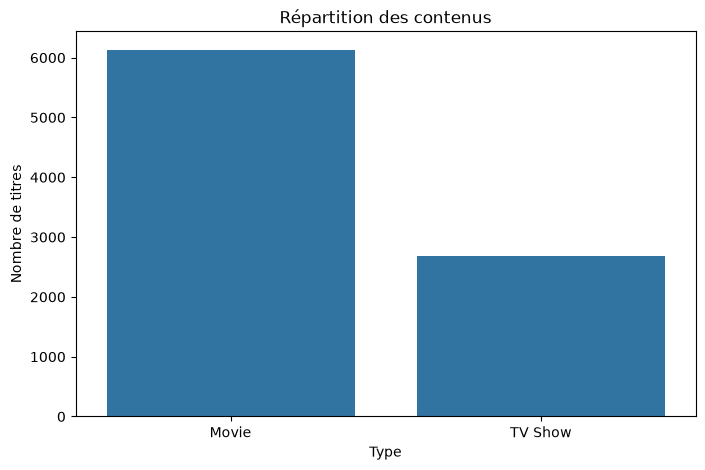

In [7]:
# Visualisation
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="type")
plt.title("Répartition des contenus")
plt.xlabel("Type")
plt.ylabel("Nombre de titres")
plt.show()

#### l’évolution du catalogue par année de sortie.

In [8]:
# Nombre de contenus par année de sortie
releases_by_year = df["release_year"].value_counts().sort_index()

releases_by_year.tail(20)

release_year
2002      51
2003      61
2004      64
2005      80
2006      96
2007      88
2008     136
2009     152
2010     194
2011     185
2012     237
2013     288
2014     352
2015     560
2016     902
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: count, dtype: int64

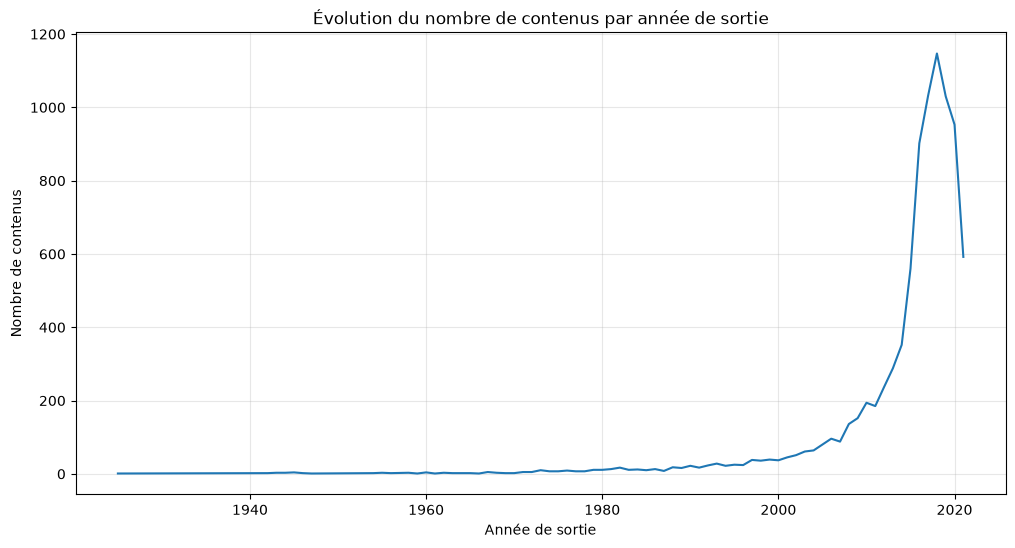

In [9]:
plt.figure(figsize=(12, 6))

plt.plot(releases_by_year.index, releases_by_year.values)

plt.title("Évolution du nombre de contenus par année de sortie")
plt.xlabel("Année de sortie")
plt.ylabel("Nombre de contenus")
plt.grid(True, alpha=0.3)

plt.show()

In [10]:
df["release_year"].value_counts().head(10)

release_year
2018    1147
2017    1032
2019    1030
2020     953
2016     902
2021     592
2015     560
2014     352
2013     288
2012     237
Name: count, dtype: int64

In [11]:
df["release_year"].value_counts().head(5).sort_index()

release_year
2016     902
2017    1032
2018    1147
2019    1030
2020     953
Name: count, dtype: int64

#### Les pays

In [12]:
# Séparer les pays et compter chaque apparition
countries = (
    df["country"]
    .str.split(", ")
    .explode()
    .value_counts()
)

countries.head(15)

country
United States     3689
India             1046
Unknown            831
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
China              162
Australia          160
Egypt              117
Turkey             113
Name: count, dtype: int64

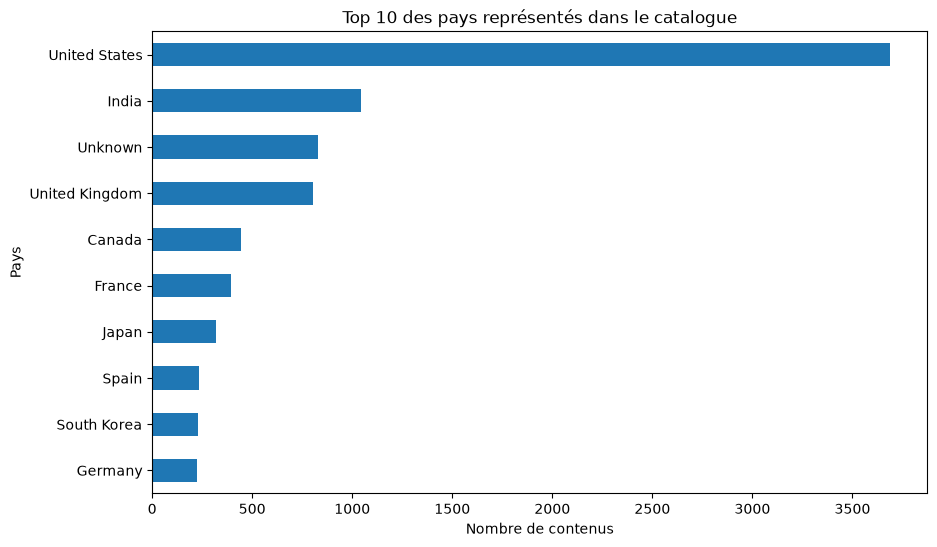

In [13]:
plt.figure(figsize=(10, 6))

countries.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 des pays représentés dans le catalogue")
plt.xlabel("Nombre de contenus")
plt.ylabel("Pays")

plt.show()

In [14]:
countries.head(10)

country
United States     3689
India             1046
Unknown            831
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Name: count, dtype: int64